# Advanced Self-Attention Variants - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Benchmark advanced attention variants for long-context efficiency and approximation quality.

## 1) Imports and Setup

In [1]:
from __future__ import annotations

import importlib.util
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}

def load_runtime_env() -> None:
    env_files = [
        Path("configs/runtime.env"),
        Path("configs/runtime.env.example"),
        Path("../configs/runtime.env"),
        Path("../configs/runtime.env.example"),
    ]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

load_runtime_env()
USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))

_torch_cuda = False
_tf_gpu = False
if importlib.util.find_spec("torch") is not None:
    import torch

    _torch_cuda = torch.cuda.is_available()
if importlib.util.find_spec("tensorflow") is not None:
    import tensorflow as tf

    tf.random.set_seed(SEED)
    _tf_gpu = bool(tf.config.list_physical_devices("GPU"))

runtime_device = "cuda" if USE_GPU and (_torch_cuda or _tf_gpu) else "cpu"
print(f"USE_GPU={int(USE_GPU)} | runtime_device={runtime_device}")

USE_GPU=1 | runtime_device=cuda


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 64
    seq_len: int = 128
    d_model: int = 48
    local_window: int = 8
    temperature_grid_size: int = 31


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=64, seq_len=128, d_model=48, local_window=8, temperature_grid_size=31)

## 3) Data Loading

In [3]:
def build_dataset(cfg: ExperimentConfig) -> np.ndarray:
    x = np.random.normal(0.0, 1.0, (cfg.num_samples, cfg.seq_len, cfg.d_model)).astype(np.float32)
    return x


x_all = build_dataset(CFG)
split = int(0.8 * CFG.num_samples)
x_train, x_test = x_all[:split], x_all[split:]
x_train.shape, x_test.shape

((51, 128, 48), (13, 128, 48))

## 4) EDA

In [4]:
token_norms = np.linalg.norm(x_all, axis=-1)
print("Token norm mean/std:", float(token_norms.mean()), float(token_norms.std()))
print("Max norm:", float(token_norms.max()))

Token norm mean/std: 6.8959245681762695 0.7052150964736938
Max norm: 9.762795448303223


## 5) Preprocessing

In [5]:
def project_qkv(x: np.ndarray, d_model: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w_q = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_k = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_v = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    return x @ w_q, x @ w_k, x @ w_v


q_train, k_train, v_train = project_qkv(x_train, CFG.d_model)
q_test, k_test, v_test = project_qkv(x_test, CFG.d_model)

## 6) Model Definition (Advanced Variants)

In [6]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def dense_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray) -> np.ndarray:
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    return softmax(scores, axis=-1) @ v

def sparse_local_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray, window: int) -> np.ndarray:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    return softmax(scores, axis=-1) @ v

def linear_attention(q: np.ndarray, k: np.ndarray, v: np.ndarray) -> np.ndarray:
    q_phi = np.maximum(q, 0.0) + 1e-3
    k_phi = np.maximum(k, 0.0) + 1e-3
    kv = np.einsum("bnd,bne->bde", k_phi, v)
    z = 1.0 / (np.einsum("bnd,bd->bn", q_phi, k_phi.sum(axis=1)) + 1e-6)
    out = np.einsum("bnd,bde,bn->bne", q_phi, kv, z)
    return out.astype(np.float32)

def grouped_query_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    num_groups: int = 4,
 ) -> np.ndarray:
    batch, seq_len, d_model = q.shape
    if d_model % num_groups != 0:
        raise ValueError(
            f"d_model ({d_model}) must be divisible by num_groups ({num_groups})."
        )
    group_dim = d_model // num_groups
    qg = q.reshape(batch, seq_len, num_groups, group_dim).transpose(0, 2, 1, 3)
    k_shared = k.reshape(batch, seq_len, num_groups, group_dim).mean(axis=2)
    v_shared = v.reshape(batch, seq_len, num_groups, group_dim).mean(axis=2)
    outputs: list[np.ndarray] = []
    for g in range(num_groups):
        scores = (qg[:, g] @ np.swapaxes(k_shared, -1, -2)) / math.sqrt(group_dim)
        out_g = softmax(scores, axis=-1) @ v_shared
        outputs.append(out_g)
    return np.stack(outputs, axis=1).transpose(0, 2, 1, 3).reshape(batch, seq_len, d_model)

## 7) Training (Tune Sparse Temperature Against Dense Teacher)

In [7]:
def sparse_with_temperature(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    window: int,
    temperature: float,
) -> np.ndarray:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / (math.sqrt(q.shape[-1]) * temperature)
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    return softmax(scores, axis=-1) @ v


teacher_train = dense_attention(q_train, k_train, v_train)
temp_grid = np.linspace(0.5, 2.0, CFG.temperature_grid_size, dtype=np.float32)
best_temp = float(temp_grid[0])
best_mse = float("inf")

for temp in temp_grid:
    student = sparse_with_temperature(q_train, k_train, v_train, CFG.local_window, float(temp))
    mse = float(np.mean((student - teacher_train) ** 2))
    if mse < best_mse:
        best_mse = mse
        best_temp = float(temp)

print({"best_temperature": best_temp, "train_mse": best_mse})

{'best_temperature': 2.0, 'train_mse': 0.32815247774124146}


## 8) Evaluation and Metrics

In [8]:
def timed_run(
    fn: Callable[..., np.ndarray],
    *args: object,
 ) -> tuple[np.ndarray, float]:
    start = time.perf_counter()
    out = fn(*args)
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    return out, elapsed_ms

teacher_test, t_dense = timed_run(dense_attention, q_test, k_test, v_test)
sparse_test, t_sparse = timed_run(
    sparse_with_temperature, q_test, k_test, v_test, CFG.local_window, best_temp
)
linear_test, t_linear = timed_run(linear_attention, q_test, k_test, v_test)
gqa_test, t_gqa = timed_run(grouped_query_attention, q_test, k_test, v_test)

metrics = {
    "dense_ms": float(t_dense),
    "sparse_ms": float(t_sparse),
    "linear_ms": float(t_linear),
    "gqa_ms": float(t_gqa),
    "sparse_mse_vs_dense": float(np.mean((sparse_test - teacher_test) ** 2)),
    "linear_mse_vs_dense": float(np.mean((linear_test - teacher_test) ** 2)),
    "gqa_mse_vs_dense": float(np.mean((gqa_test - teacher_test) ** 2)),
}
metrics

{'dense_ms': 0.8041060000323341,
 'sparse_ms': 0.8750219999456021,
 'linear_ms': 3.1152100000326755,
 'gqa_ms': 2.8499750001174107,
 'sparse_mse_vs_dense': 0.39095789194107056,
 'linear_mse_vs_dense': 0.2750851511955261,
 'gqa_mse_vs_dense': 0.3297136723995209}

## 9) Results Visualization

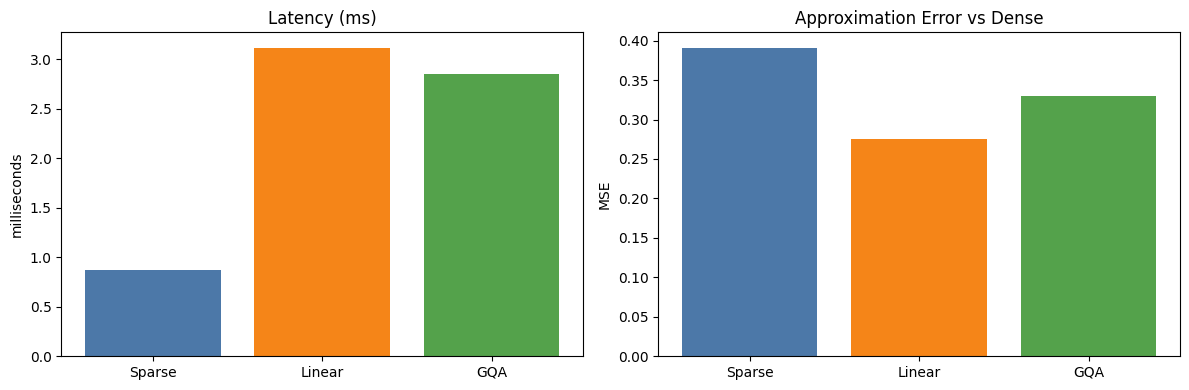

In [9]:
names = ["Sparse", "Linear", "GQA"]
latency = [metrics["sparse_ms"], metrics["linear_ms"], metrics["gqa_ms"]]
mse = [
    metrics["sparse_mse_vs_dense"],
    metrics["linear_mse_vs_dense"],
    metrics["gqa_mse_vs_dense"],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, latency, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Latency (ms)")
axes[0].set_ylabel("milliseconds")

axes[1].bar(names, mse, color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Approximation Error vs Dense")
axes[1].set_ylabel("MSE")

plt.tight_layout()
plt.show()

In [10]:
comparison_rows = [
    {
        "variant": "Dense (reference)",
        "latency_ms": metrics["dense_ms"],
        "mse_vs_dense": 0.0,
    },
    {
        "variant": "Sparse",
        "latency_ms": metrics["sparse_ms"],
        "mse_vs_dense": metrics["sparse_mse_vs_dense"],
    },
    {
        "variant": "Linear",
        "latency_ms": metrics["linear_ms"],
        "mse_vs_dense": metrics["linear_mse_vs_dense"],
    },
    {
        "variant": "GQA",
        "latency_ms": metrics["gqa_ms"],
        "mse_vs_dense": metrics["gqa_mse_vs_dense"],
    },
]

sorted_by_latency = sorted(comparison_rows, key=lambda row: row["latency_ms"])
sorted_by_error = sorted(comparison_rows, key=lambda row: row["mse_vs_dense"])

print("Benchmark Summary Table")
print("Variant            | Latency (ms) | MSE vs Dense")
print("-------------------+--------------+--------------")
for row in comparison_rows:
    print(
        f"{row['variant']:<18} | {row['latency_ms']:>12.3f} | {row['mse_vs_dense']:>12.6f}"
    )

print("\nBest by latency:", sorted_by_latency[0]["variant"])
print("Best by fidelity:", sorted_by_error[0]["variant"])

Benchmark Summary Table
Variant            | Latency (ms) | MSE vs Dense
-------------------+--------------+--------------
Dense (reference)  |        0.804 |     0.000000
Sparse             |        0.875 |     0.390958
Linear             |        3.115 |     0.275085
GQA                |        2.850 |     0.329714

Best by latency: Dense (reference)
Best by fidelity: Dense (reference)


## 10) Summary
- Implemented advanced attention variants: sparse local, linear attention, and grouped-query attention.
- Tuned sparse-attention temperature against a dense-attention teacher on train split.
- Compared latency and approximation error on test split to inform enterprise serving trade-offs.